In [24]:
import sys
print(sys.executable)

C:\Projects\uczenie_glembokie_projekt\.venv\Scripts\python.exe


In [25]:
import glob
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
import kagglehub

path = kagglehub.dataset_download("cantonioupao/oxford-flower-17categories-labelled")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\natii\.cache\kagglehub\datasets\cantonioupao\oxford-flower-17categories-labelled\versions\1


In [27]:
# Wczytanie danych z folderu 17FlowerOxfordDataset
labels = []
imgs = []

# Iteracja po każdym folderze gatunku
for folder in glob.glob(f"{path}/17FlowerOxfordDataset/*/"):
    flower_name = os.path.basename(folder.rstrip(os.path.sep))
    
    # Iteracja po wszystkich obrazach JPG w folderze
    for img_path in glob.glob(folder + "*.jpg"):
        labels.append(flower_name)
        
        # Wczytanie i skalowanie obrazu
        image = keras.utils.load_img(img_path, target_size=(128, 128))
        input_arr = keras.utils.img_to_array(image)
        imgs.append(input_arr)

In [28]:
# Konwersja na numpy arrays
imgs = np.array(imgs) / 255.0  # normalizacja do zakresu [0, 1]
labels = np.array(labels)

In [29]:
print(f"Wczytano {len(imgs)} obrazów")
print(f"Liczba klas: {len(np.unique(labels))}")
print("Gatunki kwiatów:")
for l in np.unique(labels):
    print(f"  - {l}")
print(f"Kształt danych: {imgs.shape}")

Wczytano 1360 obrazów
Liczba klas: 15
Gatunki kwiatów:
  - bluebell
  - buttercup
  - cowslip
  - crocus
  - daffodil
  - daisy
  - dandelion
  - fritillary
  - iris
  - pansy
  - snowdrop
  - sunflower
  - tiger lily
  - tulip
  - windflower
Kształt danych: (1360, 128, 128, 3)


## Wstępna eksploracja danych


Rozkład klas:
----------------------------------------
bluebell             :  80 obrazów
buttercup            :  80 obrazów
cowslip              :  80 obrazów
crocus               :  80 obrazów
daffodil             :  80 obrazów
daisy                :  85 obrazów
dandelion            : 160 obrazów
fritillary           :  80 obrazów
iris                 :  80 obrazów
pansy                :  80 obrazów
snowdrop             : 160 obrazów
sunflower            :  75 obrazów
tiger lily           :  80 obrazów
tulip                :  80 obrazów
windflower           :  80 obrazów

Razem: 1360 obrazów
Min próbek na klasę: 75
Max próbek na klasę: 160


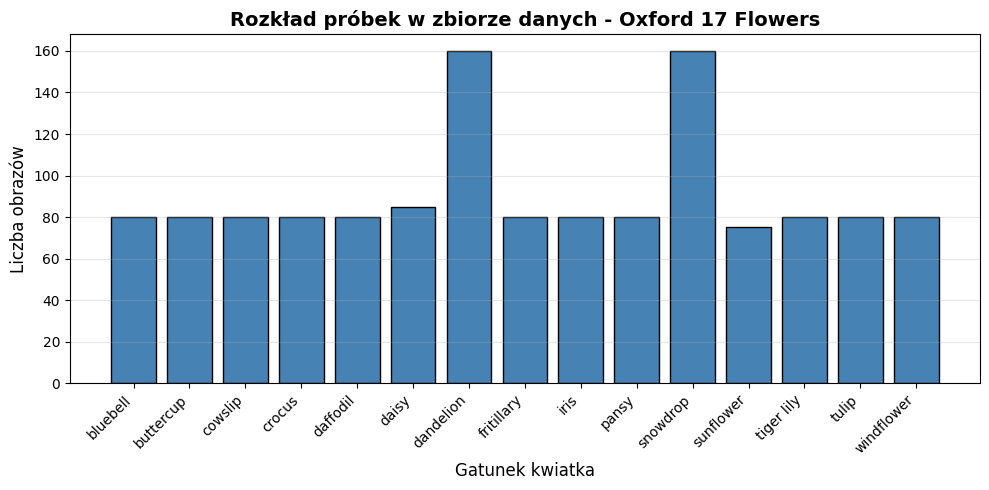

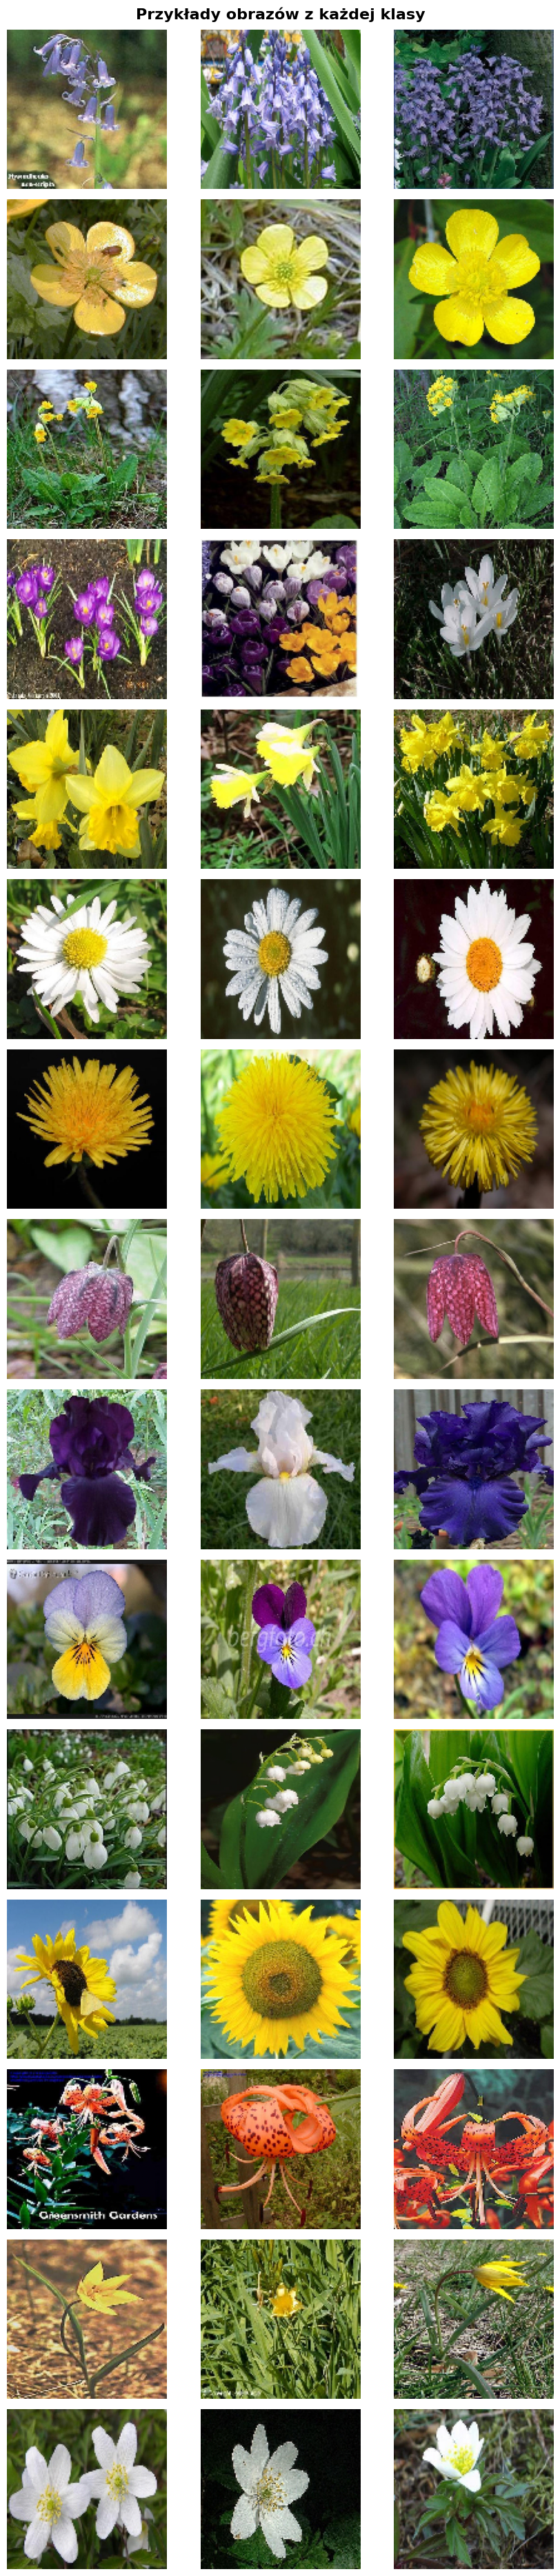

In [30]:
# Liczba próbek na klasę
class_counts = {}
for label in labels:
    class_counts[label] = class_counts.get(label, 0) + 1

print("Rozkład klas:")
print("-" * 40)
for flower, count in sorted(class_counts.items()):
    print(f"{flower:20} : {count:3} obrazów")

print(f"\nRazem: {sum(class_counts.values())} obrazów")
print(f"Min próbek na klasę: {min(class_counts.values())}")
print(f"Max próbek na klasę: {max(class_counts.values())}")

# Wizualizacja rozkładu klas
plt.figure(figsize=(10, 5))
flowers = sorted(class_counts.keys())
counts = [class_counts[f] for f in flowers]

plt.bar(flowers, counts, color='steelblue', edgecolor='black')
plt.xlabel('Gatunek kwiatka', fontsize=12)
plt.ylabel('Liczba obrazów', fontsize=12)
plt.title('Rozkład próbek w zbiorze danych - Oxford 17 Flowers', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Wyświetl kilka obrazów z każdej klasy
n_classes = len(le.classes_)
n_samples_per_class = 3

fig, axes = plt.subplots(
    n_classes,
    n_samples_per_class,
    figsize=(3 * n_samples_per_class, 2.5 * n_classes),
    # dpi=
)

for class_idx, flower_name in enumerate(sorted(class_counts.keys())):
    # Znajdź indeksy obrazów dla danej klasy
    class_indices = np.where(labels == flower_name)[0]
    # Losowo wybierz kilka obrazów
    selected_indices = np.random.choice(class_indices, n_samples_per_class, replace=False)
    
    for sample_idx, img_idx in enumerate(selected_indices):
        ax = axes[class_idx, sample_idx]
        ax.imshow(imgs[img_idx])
        ax.axis('off')
        
        if sample_idx == 0:
            ax.set_ylabel(flower_name, fontsize=11, fontweight='bold', rotation=0, ha='right', labelpad=15)

plt.suptitle('Przykłady obrazów z każdej klasy', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [31]:
# Zamiana etykiet tekstowych na numeryczne
le = LabelEncoder()
y = le.fit_transform(labels)
y = keras.utils.to_categorical(y)

# Podział na zbiory train/val/test (70% train, 15% val, 15% test)
X_train, X_test, y_train, y_test = train_test_split(imgs, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"\nPodział danych:")
print(f"TRAIN: {X_train.shape}")
print(f"VAL:   {X_val.shape}")
print(f"TEST:  {X_test.shape}")


Podział danych:
TRAIN: (924, 128, 128, 3)
VAL:   (232, 128, 128, 3)
TEST:  (204, 128, 128, 3)


## Budowa modelu CNN


In [35]:
from keras import layers, models

# Liczba klas wyliczona ze zmiennej y (one-hot)
n_classes = y.shape[1]
print(f"Liczba wykrytych klas: {n_classes}")

model = models.Sequential([
    # Blok 1: Conv → Conv → MaxPool → Dropout
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    # Blok 2: Conv → Conv → MaxPool → Dropout
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    # Blok 3: Conv → Conv → MaxPool → Dropout
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    # Warstwy w pełni połączone (Dense)
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    # Wyjście: n_classes
    layers.Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("=" * 60)
print("ARCHITEKTURA MODELU")
print("=" * 60)
model.summary()

Liczba wykrytych klas: 15
ARCHITEKTURA MODELU


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │      16,777,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,926,735 (68.39 MB)

 Trainable params: 17,926,735 (68.39 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
import json
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1464 - loss: 2.5512
Epoch 1: val_loss improved from None to 2.26368, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.1851 - loss: 2.4754 - val_accuracy: 0.2543 - val_loss: 2.2637
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2464 - loss: 2.2981
Epoch 2: val_loss improved from 2.26368 to 2.10363, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.2413 - loss: 2.2855 - val_accuracy: 0.3276 - val_loss: 2.1036
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2707 - loss: 2.1644
Epoch 3: val_loss improved from 2.10363 to 1.87982, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.2868 - loss: 2.1370 - val_accuracy: 0.3491 - val_loss: 1.879

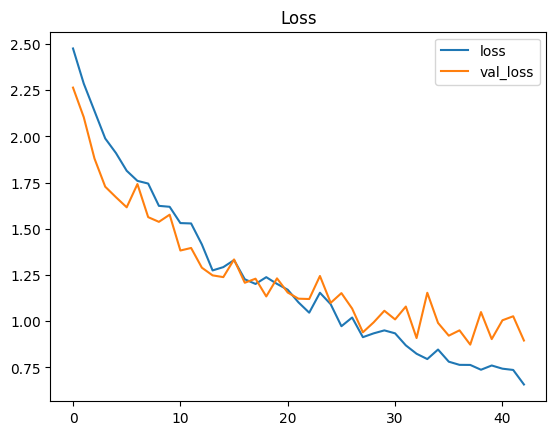

In [ ]:
# --- Hiperparametry (zapisujemy to do pliku) ---
epochs = 50
batch_size = 32
optimizer = 'adam'
loss = 'categorical_crossentropy'

# (Prze)kompilujemy model z wybranym optymaizerem i stratą
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Generatory (augmentacja dla zbioru treningowego)
train_datagen = ImageDataGenerator(rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size)

# Callbacki: zapis najlepszego modelu i early stopping
checkpoint_path = 'best_model.keras'
checkpoint_cb = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Trening z walidacją (z callbackami)
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb]
)

# Zapis hiperparametrów użytych w treningu
training_config = {
    'epochs': epochs,
    'batch_size': batch_size,
    'optimizer': optimizer,
    'loss': loss
}
print('Training config:', training_config)
with open('training_config.json', 'w') as f:
    json.dump(training_config, f)

# Zapis historii treningu
with open('history.json', 'w') as f:
    json.dump(history.history, f)

# Wykresy przebiegu treningu
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

print('Best model (by val_loss) saved to:', checkpoint_path)

In [40]:
from keras import layers as klayers

Kształt filtrów: (3, 3, 3, 64)


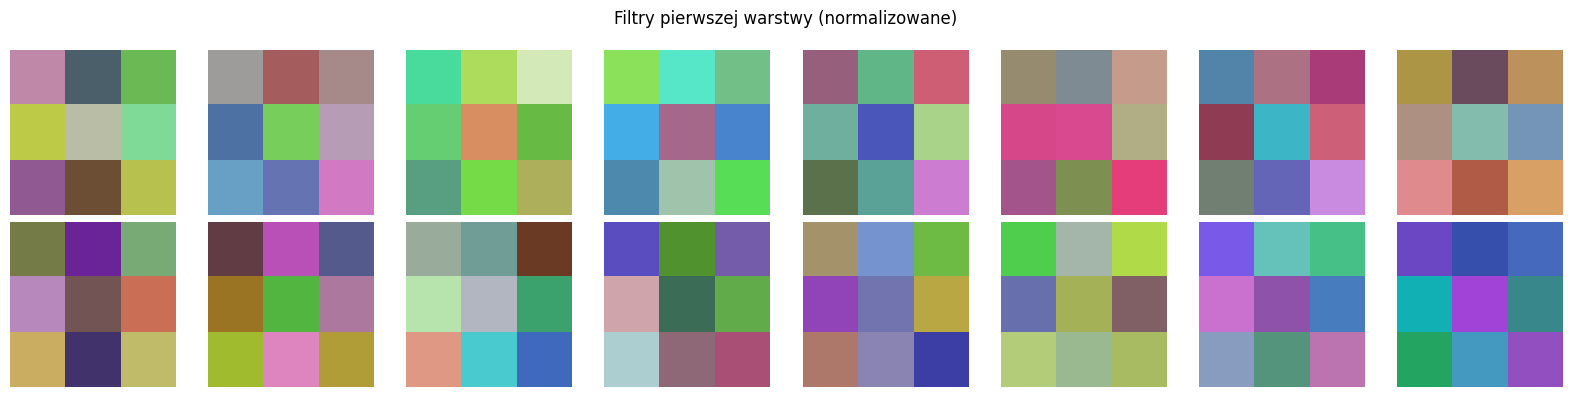

In [44]:
# Wizualizacja filtrów pierwszej warstwy

# Znajdź pierwszą warstwę Conv2D
conv_layer = None
for l in model.layers:
    if isinstance(l, klayers.Conv2D):
        conv_layer = l
        break

if conv_layer is None:
    print("Nie znaleziono warstwy Conv2D w modelu")
else:
    filters, biases = conv_layer.get_weights()
    print("Kształt filtrów:", filters.shape)

    # Normalizacja filtrów do zakresu [0,1]
    f_min, f_max = filters.min(), filters.max()
    filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

    # Liczba filtrów do wyświetlenia
    n_filters = min(filters_norm.shape[-1], 16)
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(n_cols * 2, n_rows * 2))

    for i in range(n_filters):
        f = filters_norm[:, :, :, i]
        ax = plt.subplot(n_rows, n_cols, i+1)
        if f.shape[2] == 3:
            plt.imshow(f)
        else:
            plt.imshow(f[:, :, 0], cmap='gray')
        plt.axis('off')

    plt.suptitle('Filtry pierwszej warstwy (normalizowane)')
    plt.tight_layout()
    plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.7598 - loss: 0.8620

Ewaluacja na zbiorze testowym:
loss: 0.8620
compile_metrics: 0.7598
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step

Classification report:
              precision    recall  f1-score   support

    bluebell       0.79      0.85      0.81        13
   buttercup       0.33      0.43      0.38         7
     cowslip       0.86      0.46      0.60        13
      crocus       0.67      0.57      0.62        14
    daffodil       0.38      0.38      0.38         8
       daisy       0.86      0.92      0.89        13
   dandelion       0.80      0.80      0.80        30
  fritillary       0.90      0.82      0.86        11
        iris       0.71      0.71      0.71        14
       pansy       1.00      0.82      0.90        11
    snowdrop       0.77      0.94      0.85        18
   sunflower       0.79      1.00      0.88        11
  tiger lily       0.77      1.00      0.87        10
       tulip       0.73      0.69     

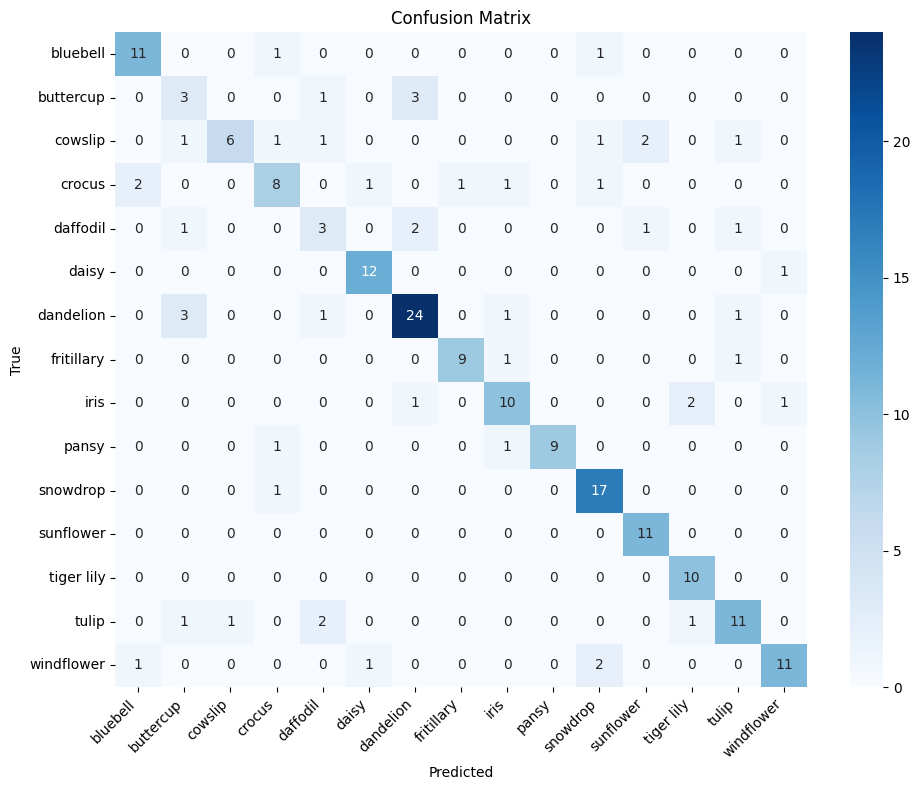


Wyniki zapisane do test_report.json


In [45]:
# Ocena na zbiorze testowym
# Podstawowa ewaluacja
results = model.evaluate(X_test, y_test, batch_size=batch_size)
print('\nEwaluacja na zbiorze testowym:')
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

# Opcjonalnie: classification_report i confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predykcje i prawdziwe etykiety (numeryczne)
y_pred = model.predict(X_test)
pred_labels = np.argmax(y_pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

print('\nClassification report:')
print(classification_report(true_labels, pred_labels, target_names=le.classes_))

# Macierz pomyłek
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Zapis wyników do pliku
import json
report = classification_report(true_labels, pred_labels, target_names=le.classes_, output_dict=True)
with open('test_report.json', 'w') as f:
    json.dump({'evaluation': dict(zip(model.metrics_names, results)), 'classification_report': report}, f)
print('\nWyniki zapisane do test_report.json')

Liczba błędnych klasyfikacji: 49 / 204
Procent błędów: 24.02%


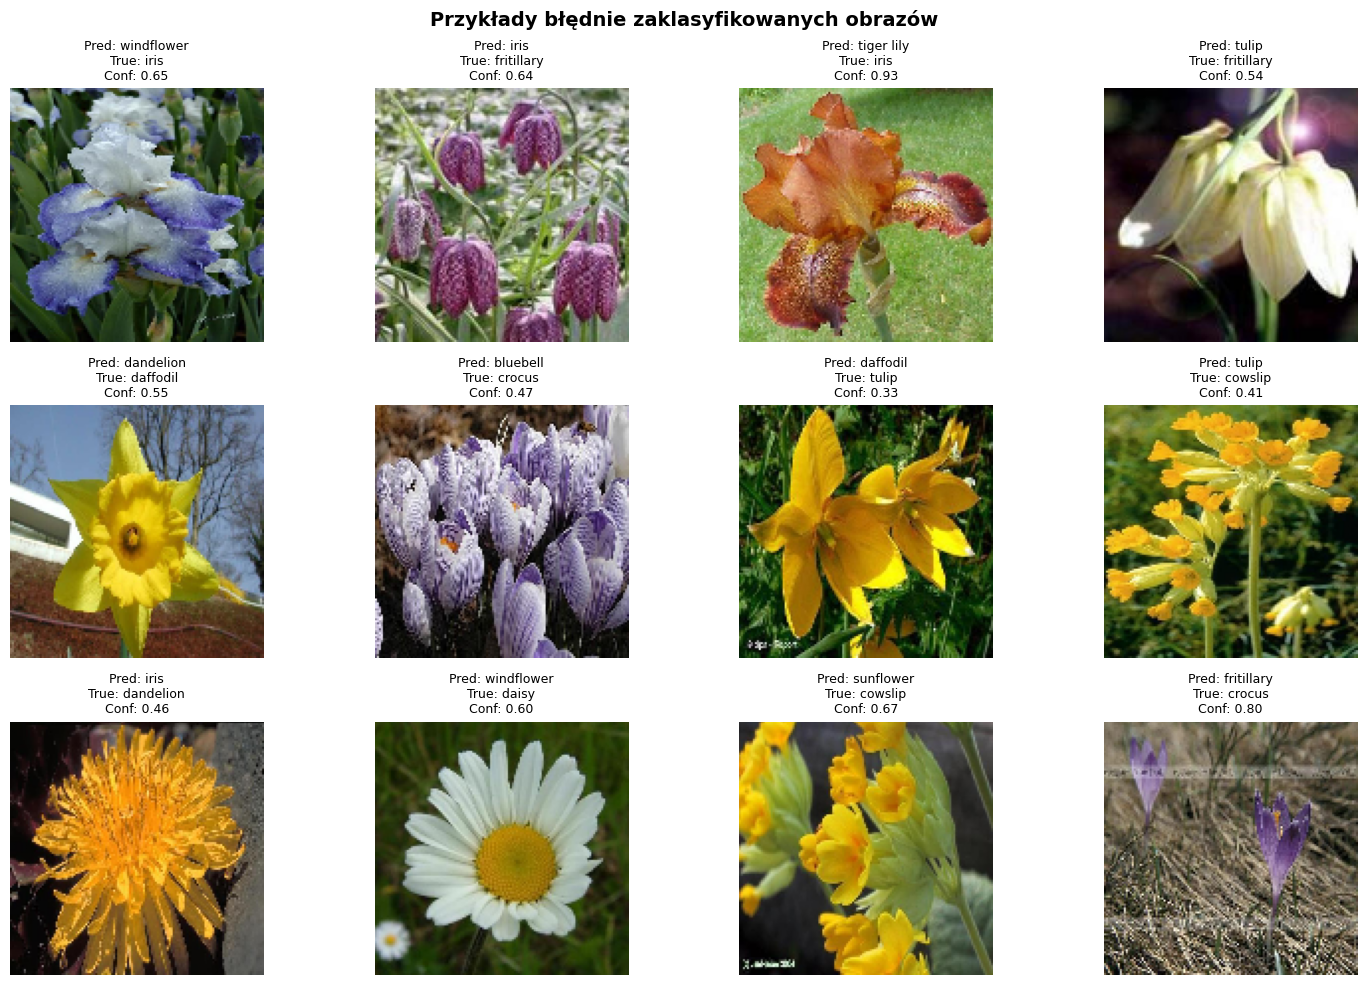

In [46]:
# Przykłady błędnych klasyfikacji
wrong_idx = np.where(pred_labels != true_labels)[0]

print(f"Liczba błędnych klasyfikacji: {len(wrong_idx)} / {len(X_test)}")
print(f"Procent błędów: {len(wrong_idx) / len(X_test) * 100:.2f}%")

if len(wrong_idx) > 0:
    plt.figure(figsize=(15, 10))
    n_samples = min(len(wrong_idx), 12)  # Wyświetlaj max 12 przykładów
    
    for i, idx in enumerate(wrong_idx[:n_samples]):
        plt.subplot(3, 4, i+1)
        plt.imshow(X_test[idx])
        pred_name = le.inverse_transform([pred_labels[idx]])[0]
        true_name = le.inverse_transform([true_labels[idx]])[0]
        pred_conf = np.max(y_pred[idx])
        
        plt.title(f"Pred: {pred_name}\nTrue: {true_name}\nConf: {pred_conf:.2f}", fontsize=9)
        plt.axis('off')
    
    plt.suptitle('Przykłady błędnie zaklasyfikowanych obrazów', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Brak błędnych klasyfikacji na zbiorze testowym!")